CREACION DE CSV


In [1]:
import pandas as pd
import numpy as np

In [2]:
np.random.seed(42)
n_registros=100

In [3]:

data = {
    'ID_Venta': range(1001, 1001 + n_registros),
    'Fecha': pd.date_range(start='2024-01-01', periods=n_registros, freq='D'),
    'Cliente': [f'Cliente_{i}' for i in range(n_registros)],
    'Monto_CLP': np.random.randint(50000, 1500000, n_registros).astype(float),
    'Depto': np.random.choice(['Computación', 'Smartphones', 'Audio', 'Gaming'], n_registros),
    'Estado': np.random.choice(['Completado', 'Pendiente', 'Cancelado'], n_registros, p=[0.7, 0.2, 0.1])
}

df = pd.DataFrame(data)

In [4]:
for _ in range(10):
    df.loc[np.random.randint(0, n_registros), 'Monto_CLP'] = np.nan
    df.loc[np.random.randint(0, n_registros), 'Depto'] = np.nan


In [5]:
duplicados = df.sample(5)

df = pd.concat([df, duplicados], ignore_index=True)


In [6]:
df.loc[df.sample(5).index, 'Estado'] = 'completado'

In [7]:
df.to_csv('datos_tecnologia_100.csv', index=False)
print("Archivo creado, registro con exito de 105")

Archivo creado, registro con exito de 105


CLEANING 

In [8]:
df = df.drop_duplicates()
print(f"Registro despues de quitar duplicados: {len(df)}")


Registro despues de quitar duplicados: 100


In [9]:
promedio_monto = df['Monto_CLP'].mean()
df['Monto_CLP'] = df['Monto_CLP'].fillna(promedio_monto)
print(f"Valor usado para completar nulos: ${promedio_monto:,.0f}")

Valor usado para completar nulos: $797,614


In [10]:
df['Estado'] = df['Estado'].str.capitalize()

In [11]:
tipo_cambio = 950
df['Monto_USD'] = df['Monto_CLP']

print("Categorias unicas de Estado:", df['Estado'].unique())

Categorias unicas de Estado: ['Completado' 'Pendiente' 'Cancelado']


In [12]:
df_smartphones = df[df['Depto'] == 'Smartphones'].copy()

df_reducido = df_smartphones.drop(columns=['Monto_CLP'])

print(f"Cantidad de registros de Smartphones: {len(df_reducido)}")

Cantidad de registros de Smartphones: 14


In [13]:
df_reducido.to_csv('resultado_final_limpio.csv', index=False)

In [14]:
print("GENERANDO RESUMEN AUTOMATICO POR DEPARTAMENTO")

departamentos = df['Depto'].dropna().unique()
for depto in departamentos:
    filtro = df[df['Depto'] == depto]

cantidad = len(filtro)
total_ventas_clp = filtro['Monto_CLP'].sum()
promedio_usd = filtro['Monto_USD'].mean()

print(f" DEPARTAMENTOS; {depto.upper()}")
print(f" N° Transacciones: {cantidad}")
print(f" Ingresos Totales: ${total_ventas_clp:,.0f} CLP")
print(f" Ticket Promedio: ${promedio_usd:,.2f} USD")
print("-" *40)

GENERANDO RESUMEN AUTOMATICO POR DEPARTAMENTO
 DEPARTAMENTOS; SMARTPHONES
 N° Transacciones: 14
 Ingresos Totales: $8,427,877 CLP
 Ticket Promedio: $601,991.20 USD
----------------------------------------


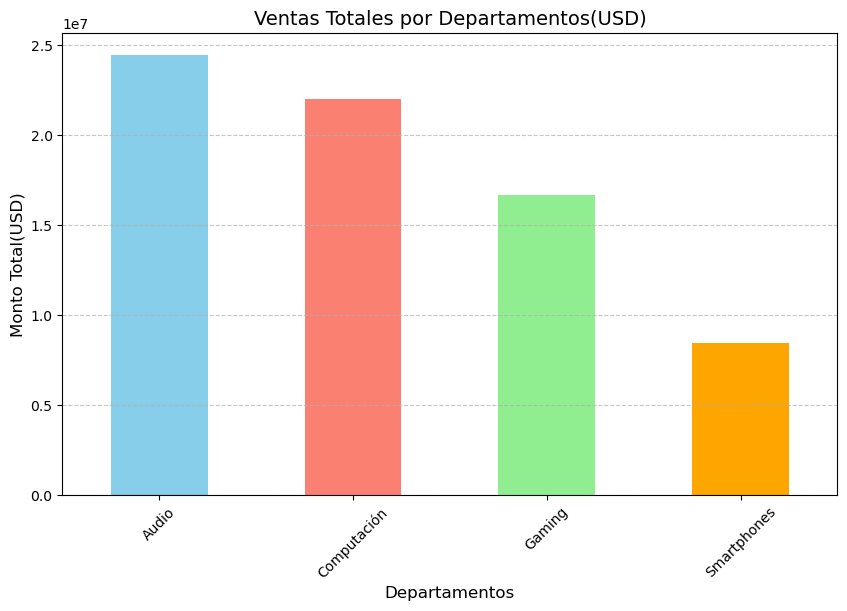

In [15]:
import matplotlib.pyplot as plt

resumen_grafico = df.groupby('Depto')['Monto_USD'].sum()

plt.figure(figsize=(10, 6))
resumen_grafico.plot(kind='bar', color=['skyblue', 'salmon', 'lightgreen', 'orange'])

plt.title("Ventas Totales por Departamentos(USD)", fontsize=14)
plt.xlabel("Departamentos", fontsize=12)
plt.ylabel("Monto Total(USD)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()